URL de origen de los datos: https://www.faconauto.com/estadisticas/matriculaciones-de-turismos/

URL fichero datos: http://fpaniaguapython.github.io/datos/CCAA-ULTIMOS-DOCE-MESES-LAPTOP-H55DSDJ2.csv

- Mes de más matriculaciones en Extremadura.
- Provincia con más matriculaciones en el mes de marzo
- Provincia con más matriculaciones en total
- Total de matriculaciones
- Diagrama de barras con los datos del mes de junio (horizontal y vertical)
- Diagrama de tartas
- Histograma por trimestres
- Diagrama de correlación entre las comunidades de Madrid y Cataluña

In [697]:
import pandas as pd
URL = 'http://fpaniaguapython.github.io/datos/CCAA-ULTIMOS-DOCE-MESES-LAPTOP-H55DSDJ2.csv'
datos = pd.read_csv(URL, sep=';', thousands='.') # 👁️ al argumento thousands
datos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   comunidad  20 non-null     object
 1   may-25     20 non-null     int64 
 2   jun-25     20 non-null     int64 
 3   jul-25     20 non-null     int64 
 4   ago-25     20 non-null     int64 
 5   sep-25     20 non-null     int64 
 6   oct-25     20 non-null     int64 
 7   nov-25     20 non-null     int64 
 8   dic-25     20 non-null     int64 
 9   ene-26     20 non-null     int64 
 10  feb-26     20 non-null     int64 
 11  mar-26     20 non-null     int64 
 12  abr-26     20 non-null     int64 
dtypes: int64(12), object(1)
memory usage: 2.2+ KB


In [698]:
datos.head()

,comunidad,may-25,jun-25,jul-25,ago-25,sep-25,oct-25,nov-25,dic-25,ene-26,feb-26,mar-26,abr-26
0,Total,112811,119145,98335,61315,85167,96784,94124,103011,73105,97083,130339,106862
1,ANDALUCIA,9200,10504,10582,7248,9472,10560,10035,10497,7731,9201,11510,9707
2,ARAGON,1401,1594,1628,1135,1448,1726,1668,1816,1206,1537,1746,1531
3,ASTURIAS,918,1304,1512,1511,1429,1475,1533,1454,916,1047,1404,1072
4,CANARIAS,4176,6646,5889,3304,4522,5581,5749,4090,2713,2608,5223,3290


## 🆑 Eliminación de la fila de Total

In [699]:
# df = datos[1:] # Eliminar haciendo slicing
df = datos.drop(0) # Eliminar haciendo drop
df.head()


,comunidad,may-25,jun-25,jul-25,ago-25,sep-25,oct-25,nov-25,dic-25,ene-26,feb-26,mar-26,abr-26
1,ANDALUCIA,9200,10504,10582,7248,9472,10560,10035,10497,7731,9201,11510,9707
2,ARAGON,1401,1594,1628,1135,1448,1726,1668,1816,1206,1537,1746,1531
3,ASTURIAS,918,1304,1512,1511,1429,1475,1533,1454,916,1047,1404,1072
4,CANARIAS,4176,6646,5889,3304,4522,5581,5749,4090,2713,2608,5223,3290
5,CANTABRIA,752,796,790,730,770,931,781,930,655,762,858,744


## 👌Reasignación de nombres de columnas y eliminación de la columna comunidad

In [700]:
# df.reset_index(drop=True, inplace=True) # Reasignamos los índices numéricos?
df.index = df['comunidad'] # Reasignamos los índices con los nombres de la comunidad?
df = df.drop(columns=['comunidad']) # Eliminar la columna 'comunidad'
df.head()

,may-25,jun-25,jul-25,ago-25,sep-25,oct-25,nov-25,dic-25,ene-26,feb-26,mar-26,abr-26
comunidad,,,,,,,,,,,,
ANDALUCIA,9200,10504,10582,7248,9472,10560,10035,10497,7731,9201,11510,9707
ARAGON,1401,1594,1628,1135,1448,1726,1668,1816,1206,1537,1746,1531
ASTURIAS,918,1304,1512,1511,1429,1475,1533,1454,916,1047,1404,1072
CANARIAS,4176,6646,5889,3304,4522,5581,5749,4090,2713,2608,5223,3290
CANTABRIA,752,796,790,730,770,931,781,930,655,762,858,744


## 🔢Conversión a número

In [701]:
# No hace falta
# df = df.apply(pd.to_numeric, errors='coerce')
# df.head()

### 🦉Mes de más matriculaciones en Extremadura.

In [702]:
mes_max = df.loc['EXTREMADURA'].idxmax()
value_max = df.loc['EXTREMADURA'].max()
print(f'Mes:{mes_max} - Matriculaciones:{value_max}')

Mes:dic-25 - Matriculaciones:1415


## 🍃Provincia con más matriculaciones en el mes de marzo


In [703]:
comunidad = df['mar-26'].idxmax()
matriculaciones = df['mar-26'].max()
print(f'Comunidad:{comunidad} - Matriculaciones:{matriculaciones}')

Comunidad:COMUNIDAD DE MADRID - Matriculaciones:61757


## 🧮 Provincia con más matriculaciones en total


In [704]:
df_acumulado = df.cumsum(axis=1) # axis=1 --> Incrementa por columnas
df['acumulado']=df_acumulado.max(axis=1) ## Añadimos una nueva columna 'acumulado' con la suma
max_comunidad=df[df['acumulado']==df['acumulado'].max()]
for comunidad in max_comunidad.index:
    print(comunidad)


COMUNIDAD DE MADRID


## 🚗Total de matriculaciones

In [705]:
df.head()
total_matriculaciones = df['acumulado'].sum()
print(total_matriculaciones)

1178081


- Diagrama de barras con los datos del mes de junio (horizontal y vertical)


<Axes: xlabel='comunidad'>

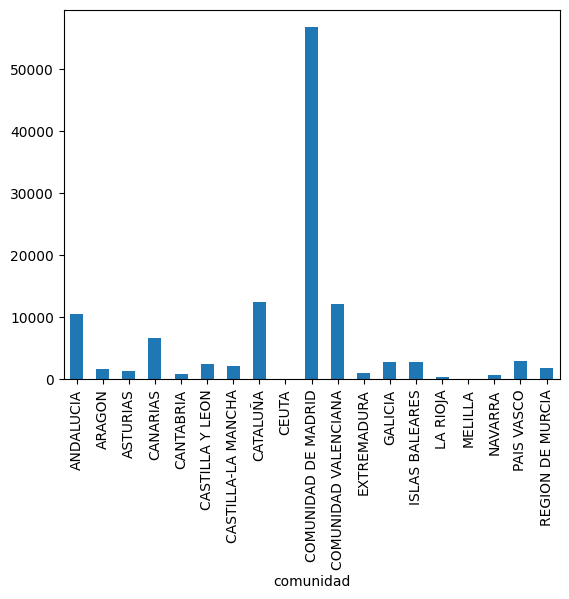

In [706]:
df['jun-25'].plot.bar()

<Axes: ylabel='comunidad'>

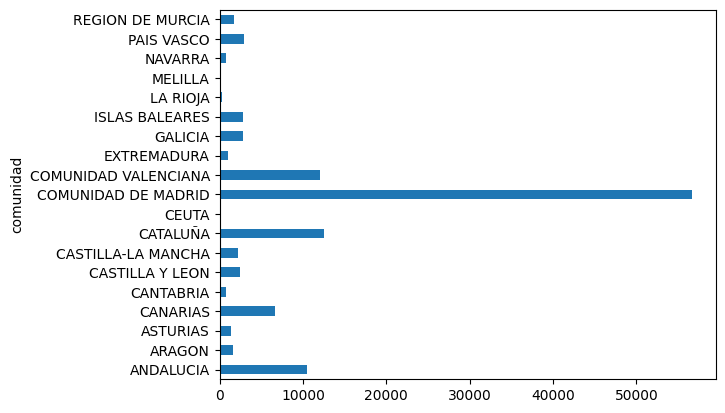

In [707]:
df['jun-25'].plot.barh()

- Diagrama de tartas

<Axes: ylabel='acumulado'>

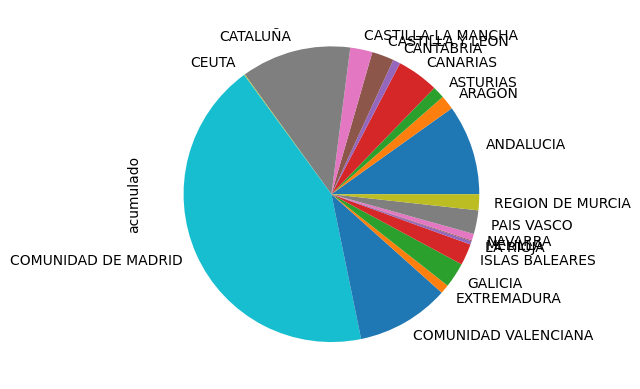

In [708]:
# Tomamos como datos los acumulados

df['acumulado'].plot.pie()

- Histograma por trimestres


<Axes: ylabel='Frequency'>

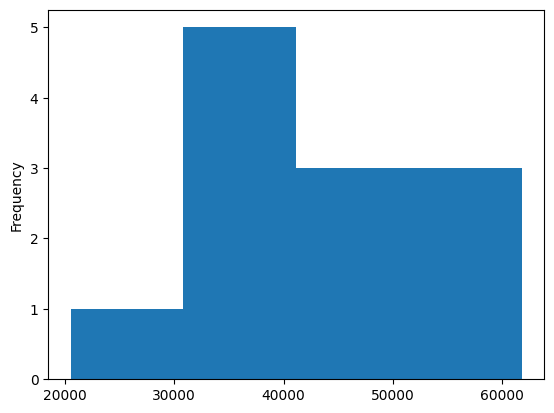

In [709]:
df.loc['COMUNIDAD DE MADRID'][:-1].plot.hist(bins=4)

- Diagrama de correlación entre las comunidades de Madrid y Cataluña

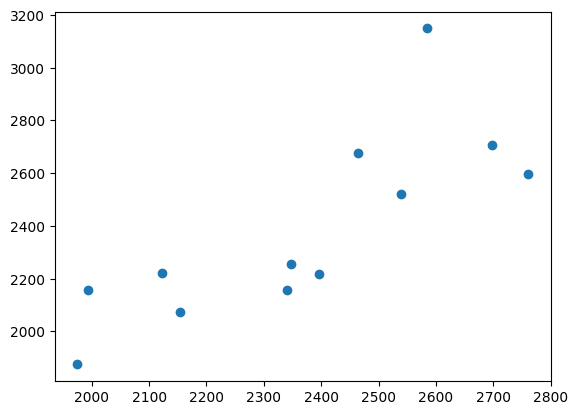

In [710]:
import matplotlib.pyplot as plt

plt.scatter(df.loc['CASTILLA Y LEON'][:-1], df.loc['CASTILLA-LA MANCHA'][:-1])
plt.show()